### 1. Install Roboflow SDK

In [1]:
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 103.0 MB/s eta 0:00:00


### 2. Download and Explore the Dataset
Replace `YOUR_ROBOFLOW_API_KEY` with your actual key from the Roboflow dashboard.

In [8]:
from roboflow import Roboflow
import os

# Initialize Roboflow
rf = Roboflow(api_key="mDwjVFSeplYuO2yfsuab")
project = rf.workspace("airlangga-university-ofdnt").project("stress-detection-fj4xx")
version = project.version(1)

# Use 'folder' format for classification projects
dataset = version.download("folder")

print(f"\nDataset Location: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Stress-Detection-1 in folder:: 100%|██████████| 992/992 [00:00<00:00, 8544.12it/s]


Dataset Location: /content/Stress-Detection-1


### 3. Understand Dataset Content
We can list the classes and check the training/validation split.

In [9]:
import os

try:
    print("--- Dataset Summary ---")
    print(f"Project Name: {project.name}")
    print(f"Project Type: {project.type}")

    # Classification projects often store class names in project metadata
    if hasattr(project, 'classes'):
        print("Classes Found:", project.classes)

    # Explore the downloaded folder structure
    train_dir = os.path.join(dataset.location, 'train')
    if os.path.exists(train_dir):
        # Check for subfolders (one per class)
        subfolders = [f for f in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, f))]
        if subfolders:
            print(f"Class subfolders: {subfolders}")
            total_imgs = sum([len(os.listdir(os.path.join(train_dir, s))) for s in subfolders])
            print(f"Total training images: {total_imgs}")
        else:
            print(f"Images found in train folder: {len(os.listdir(train_dir))}")

except NameError:
    print("Error: 'dataset' is not defined. Please run cell 2288c829 successfully first.")
except Exception as e:
    print(f"An error occurred: {e}")

--- Dataset Summary ---
Project Name: Stress Detection
Project Type: classification
Classes Found: {'Non': 594, 'Stress': 981}
Class subfolders: ['Non Stress', 'Stress']
Total training images: 785


### 4. Visualize Sample Images
Let's look at examples from each class folder.

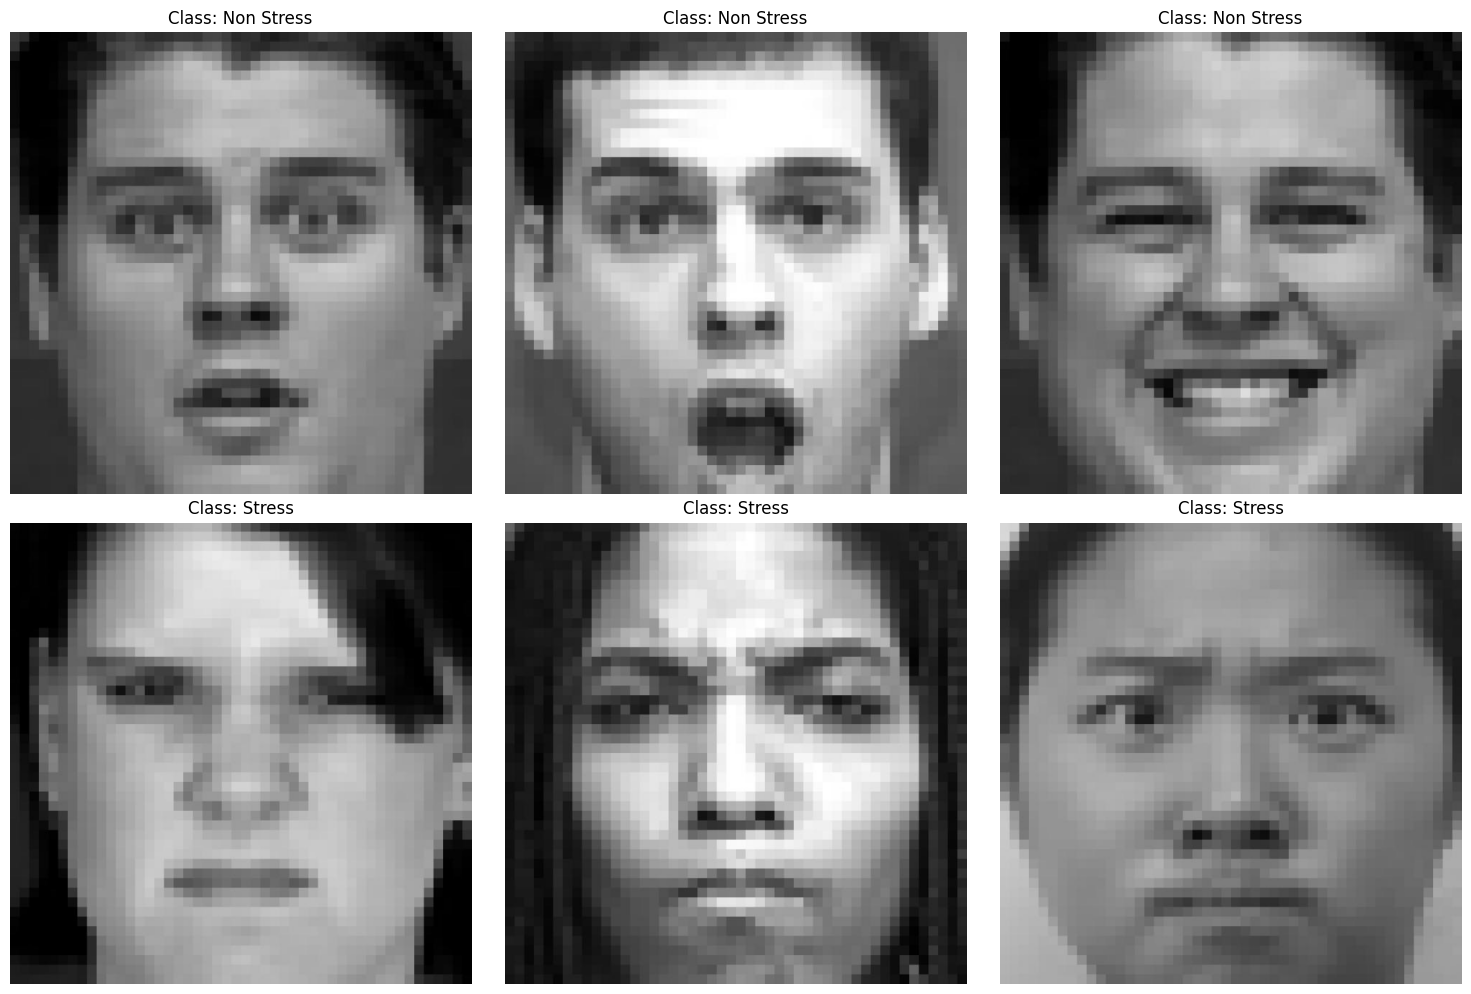

In [10]:
import matplotlib.pyplot as plt
import cv2
import glob

def plot_samples(base_path, split='train', num_samples=3):
    classes = [f for f in os.listdir(os.path.join(base_path, split)) if os.path.isdir(os.path.join(base_path, split, f))]
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(15, 5 * len(classes)))

    for i, cls in enumerate(classes):
        img_paths = glob.glob(os.path.join(base_path, split, cls, "*"))[:num_samples]
        for j, img_path in enumerate(img_paths):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax = axes[i, j] if len(classes) > 1 else axes[j]
            ax.imshow(img)
            ax.set_title(f"Class: {cls}")
            ax.axis('off')
    plt.tight_layout()
    plt.show()

if 'dataset' in locals():
    plot_samples(dataset.location)
else:
    print("Dataset not found.")

### 5. Data Preprocessing
We will use `tensorflow.keras` to load images, resize them to 224x224 (standard for MobileNet), and normalize pixel values.

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 1. First Generator for Training and Validation (80% of data)
train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 20% of the 90% goes to validation
)

# 2. Generator for Testing (Remaining 10% of data - manually using seed/shuffling or separate dir)
# Note: If Roboflow provided a 'test' folder, we use it directly.
test_datagen = ImageDataGenerator(rescale=1./255)

train_path = os.path.join(dataset.location, 'train')
test_path = os.path.join(dataset.location, 'test')
valid_path = os.path.join(dataset.location, 'valid')

# Using Roboflow's default splits if they exist, otherwise creating them
if os.path.exists(test_path) and os.path.exists(valid_path):
    print("Using pre-defined splits from Roboflow...")
    train_generator = test_datagen.flow_from_directory(train_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
    val_generator = test_datagen.flow_from_directory(valid_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
    test_generator = test_datagen.flow_from_directory(test_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)
else:
    print("Defining splits from training folder...")
    train_generator = train_val_datagen.flow_from_directory(train_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', subset='training')
    val_generator = train_val_datagen.flow_from_directory(train_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', subset='validation')
    # In this case, test data would typically be a separate download or manual split

Using pre-defined splits from Roboflow...
Found 785 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
Found 98 images belonging to 2 classes.


### 6. Build and Train Model (MobileNetV2)
We'll use a pre-trained MobileNetV2 base and add a custom classification head.

In [16]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load pre-trained MobileNetV2 without the top layer
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze the base

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 1000ms/step - accuracy: 0.6420 - loss: 0.6853 - val_accuracy: 0.8265 - val_loss: 0.3795
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.7796 - loss: 0.4466 - val_accuracy: 0.8980 - val_loss: 0.2972
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.8548 - loss: 0.3276 - val_accuracy: 0.8980 - val_loss: 0.2579
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.8892 - loss: 0.2800 - val_accuracy: 0.9388 - val_loss: 0.2236
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.8866 - loss: 0.2722 - val_accuracy: 0.8673 - val_loss: 0.2369
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.9108 - loss: 0.2192 - val_accuracy: 0.9490 - val_loss: 0.1735
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.9325 - loss: 0.1810 - val_accuracy: 0.9694 - val_loss: 0.1656
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.9529 - loss: 0.1575 - val_accuracy: 0.

### 7. Evaluate Model Performance
Now we use the `test_generator` to check how the model performs on data it has never seen during training or validation.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9694 - loss: 0.1338

Test Accuracy: 0.97
Test Loss: 0.13


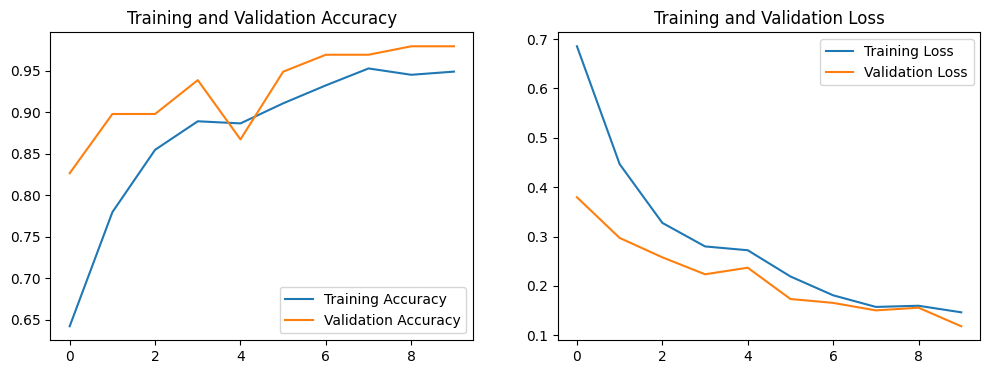

In [17]:
import matplotlib.pyplot as plt

# Evaluate on test set
if 'model' in locals() and 'test_generator' in locals():
    test_loss, test_acc = model.evaluate(test_generator)
    print(f"\nTest Accuracy: {test_acc:.2f}")
    print(f"Test Loss: {test_loss:.2f}")
else:
    print("Model or test_generator not found. Please run the previous cells.")

# Plot training history
if 'history' in locals():
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()
else:
    print("\nHistory object not found. Run the training cell (76f4ecfa) to generate training plots.")

### 8. Comprehensive Model Visualizations
Below we generate the Training History, Confusion Matrix, and sample predictions.

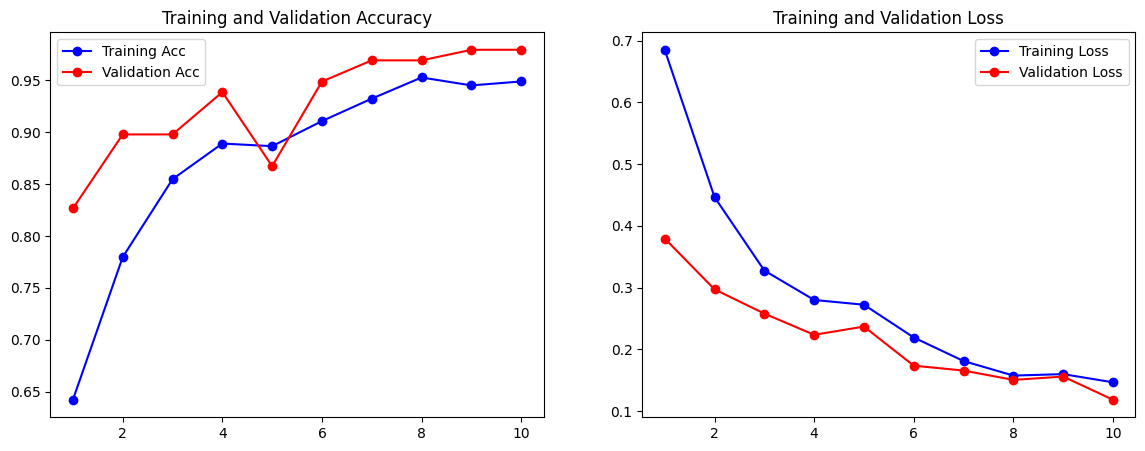


--- Confusion Matrix ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step


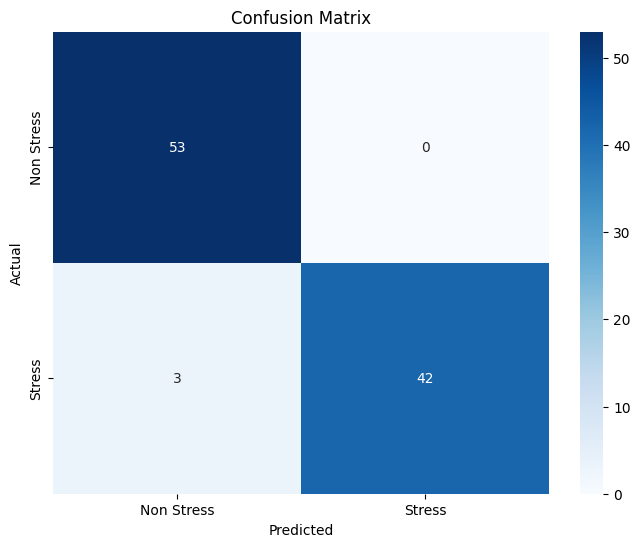


--- Sample Predictions ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


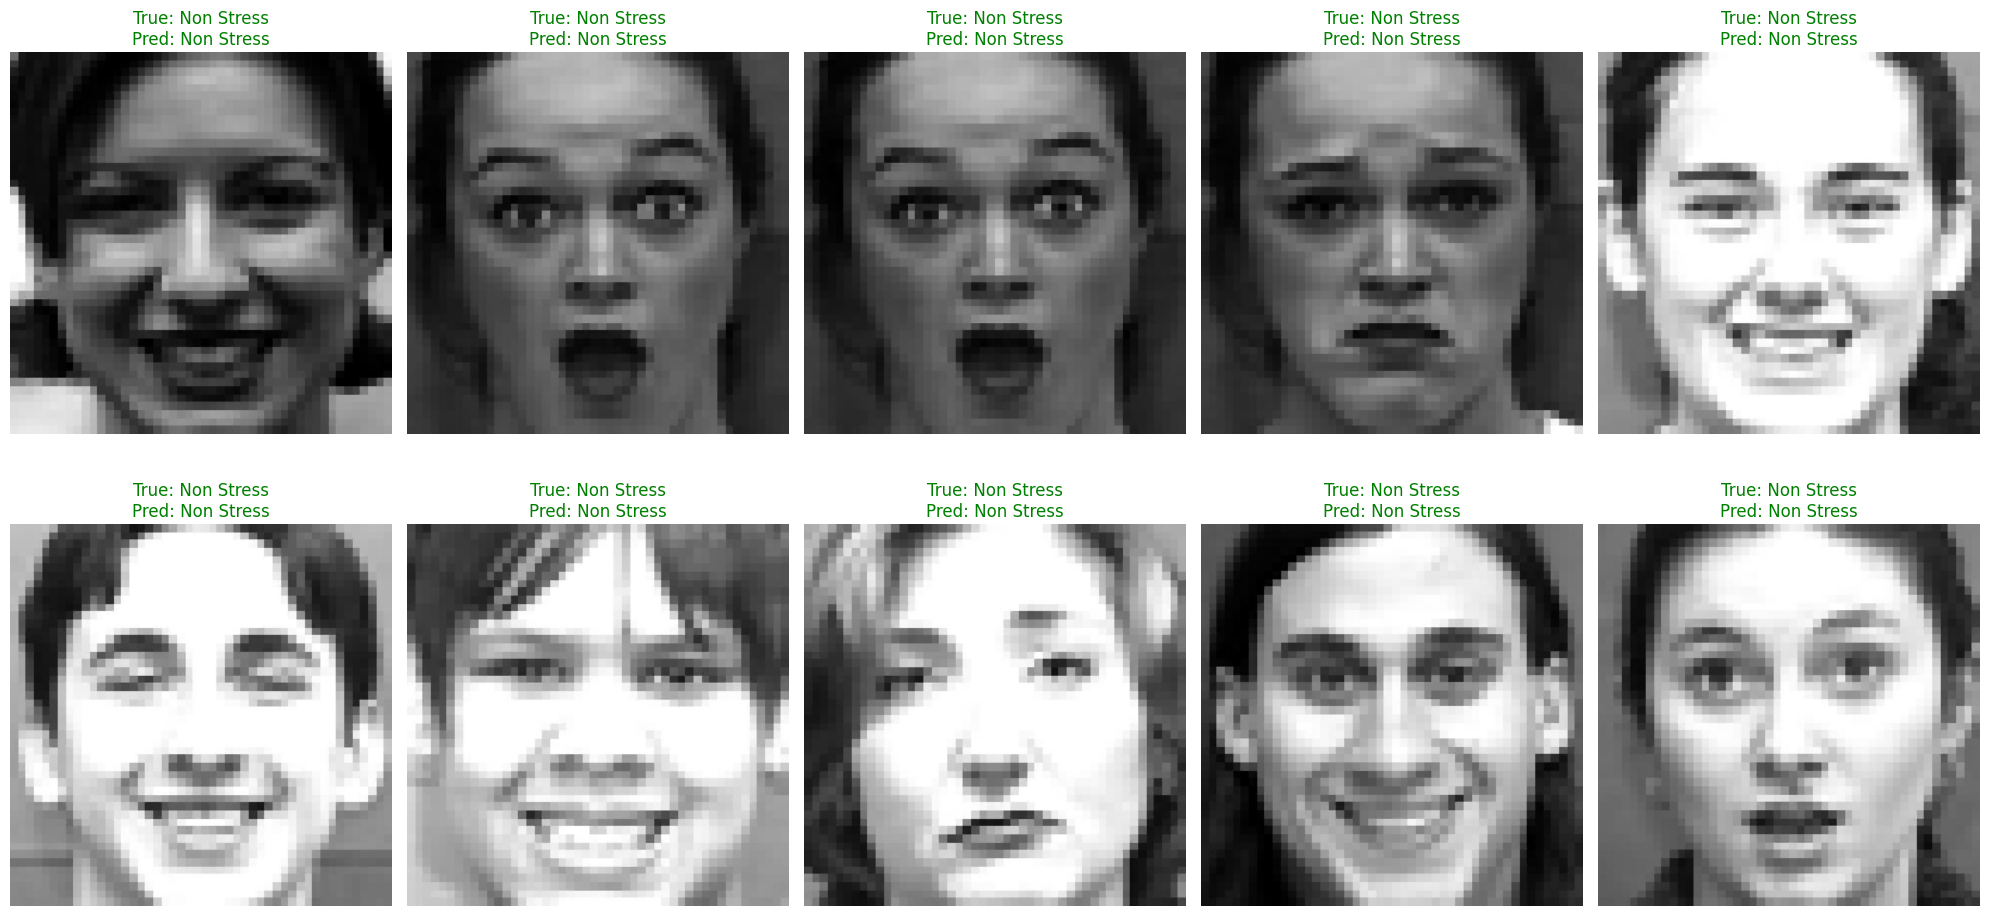

In [18]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Plot Training History (Redundant but unified here)
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

# 2. Confusion Matrix
def plot_confusion_matrix(model, generator):
    # Get predictions
    generator.reset()
    y_pred_probs = model.predict(generator)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()
    y_true = generator.classes

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(generator.class_indices.keys()),
                yticklabels=list(generator.class_indices.keys()))
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# 3. Visualizing Sample Predictions
def visualize_predictions(model, generator, num_images=10):
    generator.reset()
    images, labels = next(generator)
    preds = model.predict(images)

    plt.figure(figsize=(20, 10))
    for i in range(min(num_images, len(images))):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i])
        pred_label = 'Stress' if preds[i] > 0.5 else 'Non Stress'
        true_label = 'Stress' if labels[i] > 0.5 else 'Non Stress'
        color = 'green' if pred_label == true_label else 'red'
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Run all visualizations
if 'history' in locals():
    plot_history(history)

if 'model' in locals() and 'test_generator' in locals():
    print("\n--- Confusion Matrix ---")
    plot_confusion_matrix(model, test_generator)

    print("\n--- Sample Predictions ---")
    visualize_predictions(model, test_generator)

### 9. Deployment: Save Model and Create Interactive UI
First, we save the model to disk. Then, we use **Gradio** to build a simple web app directly in this notebook.

In [19]:
# Save the model
model.save('stress_detection_model.h5')
print("Model saved as stress_detection_model.h5")

# Install Gradio for deployment UI
!pip install -q gradio

Model saved as stress_detection_model.h5


### 10. Download Model to Local Machine
Run this cell to download the trained model file.

In [22]:
from google.colab import files

# This will initiate a download to your local computer
files.download('stress_detection_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 11. Download Dataset to Local Machine
Run this cell to zip the downloaded Roboflow dataset and download it as a single file.

In [23]:
import shutil
from google.colab import files

# Define the folder to zip and the output filename
folder_to_zip = dataset.location
output_filename = 'stress_detection_dataset.zip'

# Create a zip archive of the dataset
shutil.make_archive('stress_detection_dataset', 'zip', folder_to_zip)

# Download the zip file
files.download(output_filename)
print(f'Started download for {output_filename}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Started download for stress_detection_dataset.zip


### Download Dataset
This cell zips the dataset folder and downloads it to your local machine.

In [24]:
import shutil
from google.colab import files

# Target directory to download
dataset_path = '/content/Stress-Detection-1'
zip_name = 'Stress-Detection-Dataset.zip'

# Create the zip file
shutil.make_archive('Stress-Detection-Dataset', 'zip', dataset_path)

# Trigger download
files.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image

# Load the labels from the generator
labels = {v: k for k, v in train_generator.class_indices.items()}

def predict_image(img):
    # Preprocess the image to match model input
    img = img.resize((224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Make prediction
    prediction = model.predict(img_array)[0][0]

    # Return probabilities for both classes
    return {
        "Stress": float(prediction),
        "Non Stress": float(1 - prediction)
    }

# Launch the Gradio interface
interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=2),
    title="Stress Detection AI",
    description="Upload an image to determine if it indicates 'Stress' or 'Non Stress'."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e9851cea0a5ddc4885.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
